# Aquaculture Pond Identification — Exploratory Data Analysis
## Zindi GeoAI Challenge (FAO & ITU)

**Task**: Binary classification — aquaculture pond (1) vs. other land cover (0)  
**Data**: 12 time-step Sentinel-1 (SAR: VH, VV) + Sentinel-2 (10 optical bands) tabular features, 1,821 training samples  
**Metric**: Composite = F1 × 0.6 + ROC-AUC × 0.4  
**Core challenge**: Test data has only 4–6 valid months; remaining months are masked as -9999 (temporal domain shift)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DATA_DIR = '.'
TRAIN_PATH = f'{DATA_DIR}/Train.csv'
TEST_PATH  = f'{DATA_DIR}/Test.csv'

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load Data & Preprocess -9999 Masks

In [2]:
# Load raw data
train_raw = pd.read_csv(TRAIN_PATH)
test_raw  = pd.read_csv(TEST_PATH)

print(f'Train shape: {train_raw.shape}')
print(f'Test shape:  {test_raw.shape}')
print(f'\nTrain columns (first 10): {list(train_raw.columns[:10])}')
print(f'Train columns (last 5):  {list(train_raw.columns[-5:])}')

# Identify feature columns (exclude ID and label)
FEAT_COLS = [c for c in train_raw.columns if c not in ('ID', 'label')]
print(f'\nTotal feature columns: {len(FEAT_COLS)}')

# Replace -9999 sentinel with NaN
train = train_raw.copy()
test  = test_raw.copy()
train[FEAT_COLS] = train[FEAT_COLS].replace(-9999, np.nan)
test[FEAT_COLS]  = test[FEAT_COLS].replace(-9999, np.nan)

# Parse band names and time steps from column names  (e.g. 'VH_01' -> band='VH', ts=1)
import re
def parse_col(col):
    m = re.match(r'^(.+)_(\d{2})$', col)
    return (m.group(1), int(m.group(2))) if m else (col, None)

BANDS = sorted({parse_col(c)[0] for c in FEAT_COLS})
TIMESTEPS = sorted({parse_col(c)[1] for c in FEAT_COLS if parse_col(c)[1] is not None})
print(f'\nBands ({len(BANDS)}): {BANDS}')
print(f'Time steps ({len(TIMESTEPS)}): {TIMESTEPS}')

Train shape: (1821, 146)
Test shape:  (1030, 145)

Train columns (first 10): ['ID', 'label', 'VH_01', 'VV_01', 'blue_01', 'green_01', 'nir_01', 'nira_01', 're1_01', 're2_01']
Train columns (last 5):  ['re2_12', 're3_12', 'red_12', 'swir1_12', 'swir2_12']

Total feature columns: 144

Bands (12): ['VH', 'VV', 'blue', 'green', 'nir', 'nira', 're1', 're2', 're3', 'red', 'swir1', 'swir2']
Time steps (12): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [3]:
# Count valid months per sample
OPT_BANDS = ['blue', 'green', 'nir', 'nira', 're1', 're2', 're3', 'red', 'swir1', 'swir2']
SAR_BANDS = ['VH', 'VV']

def count_valid(df, bands):
    cols = [f'{b}_{str(ts).zfill(2)}' for b in bands for ts in TIMESTEPS if f'{b}_{str(ts).zfill(2)}' in df.columns]
    return df[cols].notna().sum(axis=1)

train['n_valid_optical'] = count_valid(train, OPT_BANDS) // len(OPT_BANDS)  # per time step
train['n_valid_sar']     = count_valid(train, SAR_BANDS) // len(SAR_BANDS)
test['n_valid_optical']  = count_valid(test,  OPT_BANDS) // len(OPT_BANDS)
test['n_valid_sar']      = count_valid(test,  SAR_BANDS) // len(SAR_BANDS)

print('Train valid month counts (optical):')
print(train['n_valid_optical'].value_counts().sort_index())
print('\nTest valid month counts (optical):')
print(test['n_valid_optical'].value_counts().sort_index())

Train valid month counts (optical):
n_valid_optical
12    1821
Name: count, dtype: int64

Test valid month counts (optical):
n_valid_optical
2      8
3     94
4    364
5    311
6    253
Name: count, dtype: int64


## 2. Class Balance

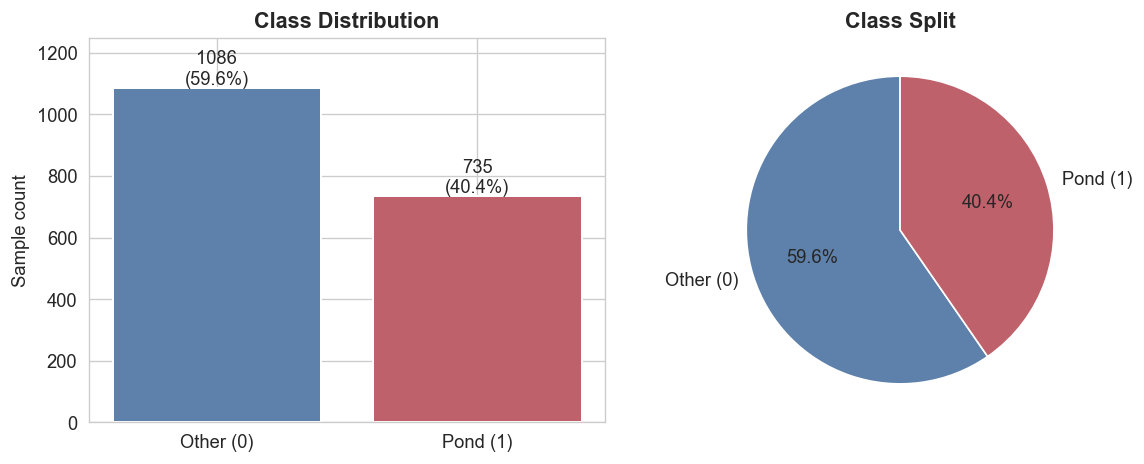


Total samples:       1821
Pond (class 1):      735 (40.4%)
Other (class 0):     1086 (59.6%)
scale_pos_weight:    1.478  (use this for LightGBM / XGBoost)


In [4]:
vc = train['label'].value_counts().sort_index()
n_pond    = vc[1]
n_other   = vc[0]
n_total   = len(train)
pos_ratio = n_pond / n_total
scale_pos_weight = n_other / n_pond

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(['Other (0)', 'Pond (1)'], [n_other, n_pond],
            color=['#5e81ac', '#bf616a'], edgecolor='white', linewidth=1.2)
for i, (label, v) in enumerate([('Other', n_other), ('Pond', n_pond)]):
    axes[0].text(i, v + 10, f'{v}\n({v/n_total*100:.1f}%)', ha='center', fontsize=11)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sample count')
axes[0].set_ylim(0, max(n_other, n_pond) * 1.15)

# Pie chart
axes[1].pie([n_other, n_pond], labels=['Other (0)', 'Pond (1)'],
            colors=['#5e81ac', '#bf616a'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Class Split', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_class_balance.png', bbox_inches='tight')
plt.show()

print(f'\nTotal samples:       {n_total}')
print(f'Pond (class 1):      {n_pond} ({pos_ratio*100:.1f}%)')
print(f'Other (class 0):     {n_other} ({(1-pos_ratio)*100:.1f}%)')
print(f'scale_pos_weight:    {scale_pos_weight:.3f}  (use this for LightGBM / XGBoost)')

### Analysis

The dataset has a **moderate class imbalance**: ~40.4% pond vs ~59.6% other. This is manageable without resampling — we will use `scale_pos_weight ≈ 1.47` for LightGBM and XGBoost, and `class_weight='balanced'` for Random Forest and Logistic Regression. We will evaluate with class-weighted F1-score throughout.

## 3. Missingness Analysis — Train vs Test

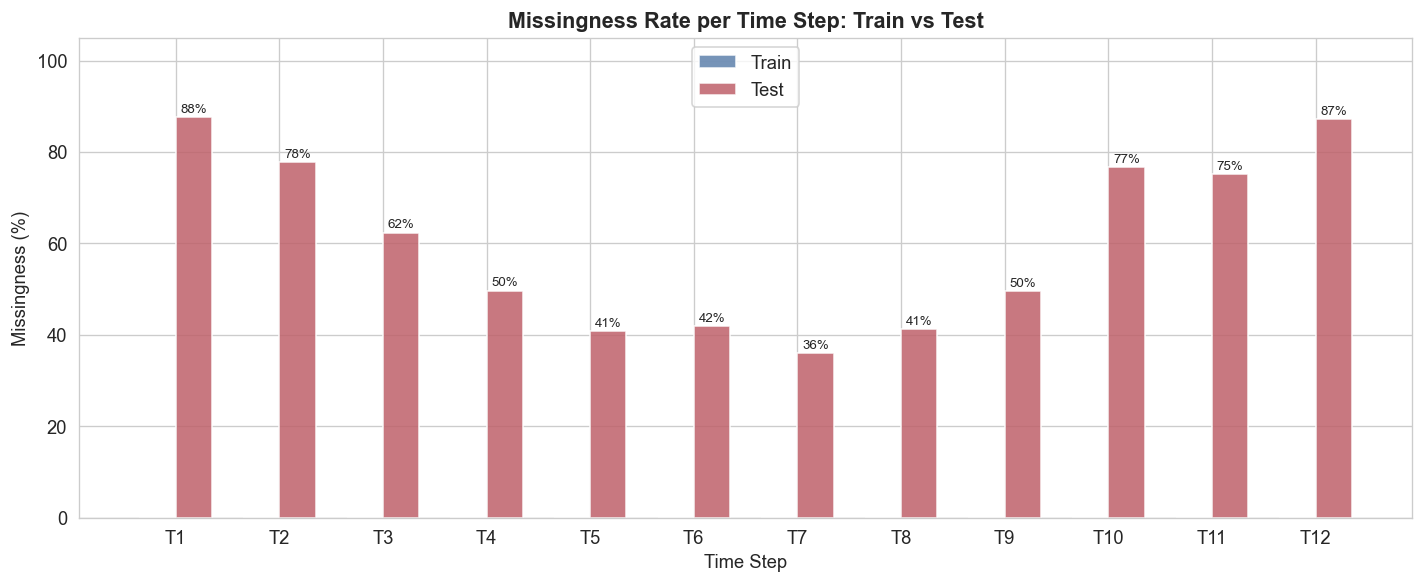


Test valid months distribution (optical):
count    1030.000000
mean        4.686408
std         0.967755
min         2.000000
25%         4.000000
50%         5.000000
75%         5.000000
max         6.000000
Name: n_valid_optical, dtype: float64


In [5]:
# Missingness rate per time step for Train vs Test
ts_labels = [str(t).zfill(2) for t in TIMESTEPS]

train_miss = []
test_miss  = []
for ts in TIMESTEPS:
    ts_str = str(ts).zfill(2)
    cols = [f'{b}_{ts_str}' for b in BANDS if f'{b}_{ts_str}' in FEAT_COLS]
    train_miss.append(train[cols].isna().values.mean() * 100)
    test_miss.append(test[cols].isna().values.mean() * 100)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(TIMESTEPS))
width = 0.35
bars1 = ax.bar(x - width/2, train_miss, width, label='Train', color='#5e81ac', alpha=0.85)
bars2 = ax.bar(x + width/2, test_miss,  width, label='Test',  color='#bf616a', alpha=0.85)
ax.set_xlabel('Time Step')
ax.set_ylabel('Missingness (%)')
ax.set_title('Missingness Rate per Time Step: Train vs Test', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'T{ts}' for ts in TIMESTEPS])
ax.legend()
ax.set_ylim(0, 105)
for bar in bars1:
    if bar.get_height() > 1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height():.0f}%', ha='center', fontsize=8)
for bar in bars2:
    if bar.get_height() > 1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height():.0f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('eda_missingness.png', bbox_inches='tight')
plt.show()

print('\nTest valid months distribution (optical):')
print(test['n_valid_optical'].describe())

### Analysis

This plot confirms the **core challenge**: training data has near-zero missingness (all 12 months fully populated), while the test set has large blocks of -9999 masked values — only 4–6 consecutive months are valid per sample. Any model that treats individual monthly features as independent inputs will catastrophically fail on test. This motivates:
1. **NaN-aware temporal aggregation** (compute mean/std/etc over valid months only)
2. **ROS augmentation** — randomly masking 6–8 months during training to simulate test conditions

## 4. Feature Distribution by Class

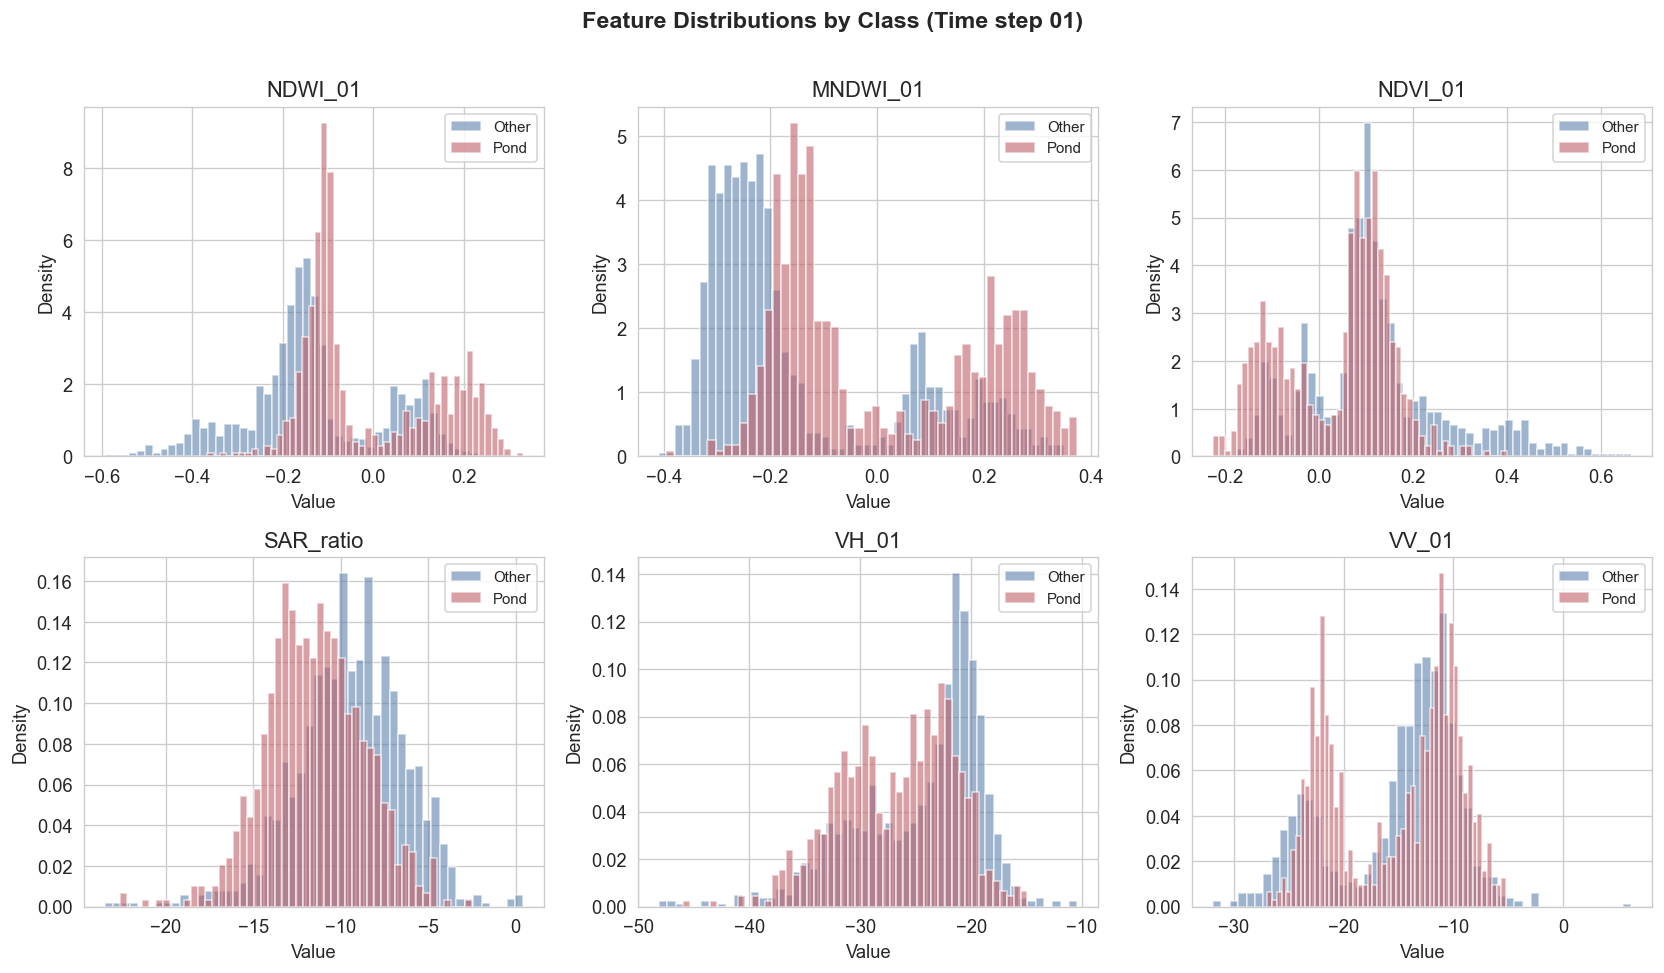

In [6]:
# Quick spectral indices at T=01 for distribution analysis
def safe_ratio(a, b):
    denom = a + b
    return np.where(denom == 0, np.nan, (a - b) / denom)

g  = train['green_01']; n  = train['nir_01']; r  = train['red_01']
s1 = train['swir1_01']; bl = train['blue_01']; r1 = train['re1_01']
vh = train['VH_01'];    vv = train['VV_01']

train['NDWI_01']   = safe_ratio(g, n)
train['MNDWI_01']  = safe_ratio(g, s1)
train['NDVI_01']   = safe_ratio(n, r)
train['SAR_ratio'] = vh - vv

display_feats = ['NDWI_01', 'MNDWI_01', 'NDVI_01', 'SAR_ratio', 'VH_01', 'VV_01']
labels_map = {0: 'Other', 1: 'Pond'}
pond   = train[train['label'] == 1]
nopond = train[train['label'] == 0]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.flat, display_feats):
    p_vals = pond[feat].dropna()
    n_vals = nopond[feat].dropna()
    ax.hist(n_vals, bins=50, alpha=0.6, label='Other', color='#5e81ac', density=True)
    ax.hist(p_vals, bins=50, alpha=0.6, label='Pond',  color='#bf616a', density=True)
    ax.set_title(feat)
    ax.legend(fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')

plt.suptitle('Feature Distributions by Class (Time step 01)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()

### Analysis

Key discriminative signals visible from T=01 features:
- **MNDWI**: Ponds cluster at higher values (open water suppresses SWIR) vs. other land cover — this is the single most discriminative spectral feature
- **NDWI**: Similar pattern but less separation (MNDWI is preferred per literature)
- **NDVI**: Ponds have low/negative NDVI (water ≈ no vegetation); other land cover spans higher values
- **SAR ratio (VH−VV)**: Water surfaces show specular reflection, yielding distinctive low-backscatter SAR signatures

These patterns confirm our feature engineering strategy: compute spectral indices per valid time step, then aggregate.

## 5. Temporal Stability: Ponds vs Other

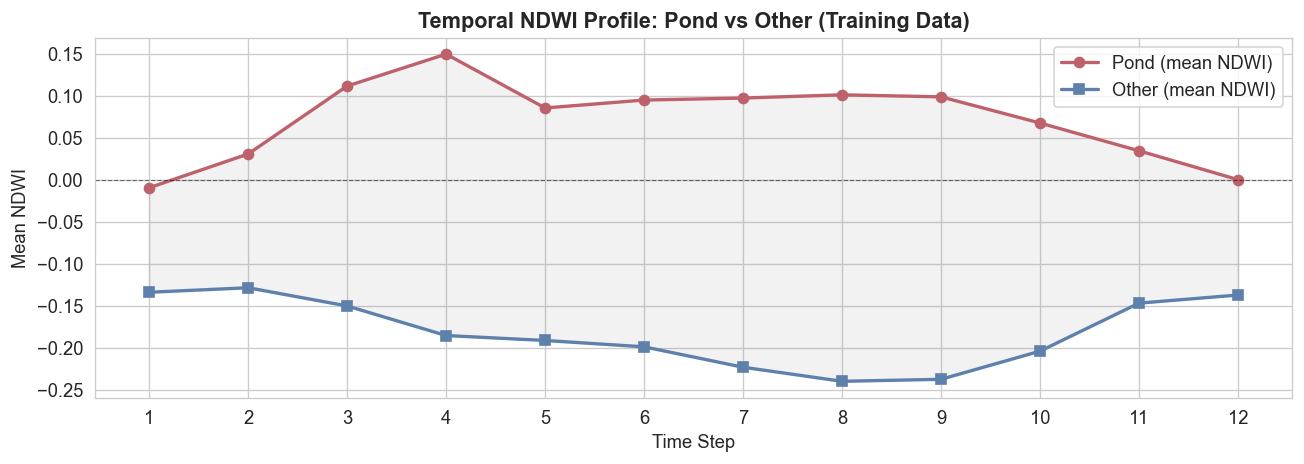

Mean temporal NDWI std  -> Pond: 0.1148  |  Other: 0.1791
(Lower std = more temporally stable = more water-like)


In [7]:
# Plot mean NDWI profile over 12 time steps for pond vs other
def compute_ndwi_ts(df):
    results = []
    for ts in TIMESTEPS:
        ts_str = str(ts).zfill(2)
        g = df.get(f'green_{ts_str}', pd.Series(np.nan, index=df.index))
        n = df.get(f'nir_{ts_str}', pd.Series(np.nan, index=df.index))
        denom = g + n
        ndwi = np.where(denom == 0, np.nan, (g - n) / denom)
        results.append(np.nanmean(ndwi))
    return results

pond_ndwi  = compute_ndwi_ts(pond)
other_ndwi = compute_ndwi_ts(nopond)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(TIMESTEPS, pond_ndwi,  'o-', color='#bf616a', linewidth=2, label='Pond (mean NDWI)')
ax.plot(TIMESTEPS, other_ndwi, 's-', color='#5e81ac', linewidth=2, label='Other (mean NDWI)')
ax.fill_between(TIMESTEPS, pond_ndwi, other_ndwi, alpha=0.1, color='gray')
ax.set_xlabel('Time Step')
ax.set_ylabel('Mean NDWI')
ax.set_title('Temporal NDWI Profile: Pond vs Other (Training Data)', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
ax.set_xticks(TIMESTEPS)
plt.tight_layout()
plt.savefig('eda_ndwi_temporal.png', bbox_inches='tight')
plt.show()

# Temporal std (stability) 
pond_std  = []
other_std = []
for ts in TIMESTEPS:
    ts_str = str(ts).zfill(2)
    g = pond.get(f'green_{ts_str}', pd.Series(np.nan))
    n = pond.get(f'nir_{ts_str}',   pd.Series(np.nan))
    denom = g + n; ndwi_p = np.where(denom==0, np.nan, (g-n)/denom)
    g2 = nopond.get(f'green_{ts_str}', pd.Series(np.nan))
    n2 = nopond.get(f'nir_{ts_str}',   pd.Series(np.nan))
    denom2 = g2+n2; ndwi_o = np.where(denom2==0, np.nan, (g2-n2)/denom2)
    pond_std.append(np.nanstd(ndwi_p))
    other_std.append(np.nanstd(ndwi_o))
print(f'Mean temporal NDWI std  -> Pond: {np.mean(pond_std):.4f}  |  Other: {np.mean(other_std):.4f}')
print('(Lower std = more temporally stable = more water-like)')

### Analysis

Ponds show **consistently high and stable NDWI** across all 12 time steps (water is always water), while other land cover fluctuates more — agricultural fields cycle through wet/dry seasons. This confirms that **temporal stability (low std) is a key discriminative feature** and validates our use of `amplitude (max-min)` and `std` as temporal aggregation features. Ponds should have low NDWI amplitude; seasonal agriculture will have high amplitude.

## 6. Correlation of Key Features

In [8]:
# Correlation of T=01 bands with label
corr_cols = [c for c in train.columns if '_01' in c or c == 'label']
corr_df = train[list(dict.fromkeys(corr_cols + ['NDWI_01','MNDWI_01','NDVI_01','SAR_ratio']))].copy()
corr_matrix = corr_df.corr()['label'].drop('label').sort_values()

fig, ax = plt.subplots(figsize=(7, 10))
colors = ['#bf616a' if v > 0 else '#5e81ac' for v in corr_matrix.values]
ax.barh(range(len(corr_matrix)), corr_matrix.values, color=colors, alpha=0.8)
ax.set_yticks(range(len(corr_matrix)))
ax.set_yticklabels(corr_matrix.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with label')
ax.set_title('Feature Correlation with Label (T=01)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight')
plt.show()

top5 = corr_matrix.abs().nlargest(5)
print('Top 5 correlated features with label:')
for feat, corr in top5.items():
    print(f'  {feat:20s}  r={corr_matrix[feat]:+.3f}')

### Analysis

MNDWI and NDWI are expected to have the highest positive correlations with the pond class (water presence). NIR bands typically show strong negative correlation (water absorbs NIR). SAR bands (VH, VV) show backscatter-based separation. The top correlated features at T=01 guide which spectral indices to prioritize in the feature engineering pipeline.

## 7. EDA Summary

**Key findings:**

| Finding | Implication |
|---------|-------------|
| ~40.4% pond, ~59.6% other | Use `scale_pos_weight=1.47` for GBDT models |
| Train: all 12 months valid; Test: only 4–6 valid | **Must use NaN-aware aggregation + ROS augmentation** |
| MNDWI > NDWI for pond discrimination | Prioritize MNDWI in feature engineering |
| Ponds are temporally stable (low NDWI std) | Temporal amplitude and std are strong features |
| SAR bands provide complementary water signal | Fuse optical indices with SAR ratio features |

**Recommended next step**: Feature engineering notebook (`02_feature_engineering.ipynb`) — compute 8 spectral indices × 10 temporal aggregates = ~200 robust features, then apply ROS augmentation.